In [1]:
# --- 日本語フォント設定（Google Colab対応） ---
!pip -q install japanize-matplotlib

# Google Colab / Jupyter 実行用
# R/S解析 と DFA を、(1) ランダムウォーク系列 と (2) Yahoo FinanceのUSDJPY（日次）に適用し、
# 各計算ステップの中間量をグラフで確認するコードです。
#
# 使い方：
# 1) そのまま実行
# 2) 下の設定（DEMO_SCALEなど）を調整
#
# 注意：
# - Yahoo Finance取得には yfinance を使用します（ネット接続が必要）
# - seabornは使いません（matplotlibのみ）

!pip -q install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from dataclasses import dataclass
import japanize_matplotlib

np.random.seed(23)

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 52.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
# -----------------------------
# Data fetch: USDJPY (Yahoo Finance)
# -----------------------------
def fetch_usdjpy_daily(start="2010-01-01", end=None):
    """
    USDJPY: yfinanceでは通常 'JPY=X' がUSD/JPY (米ドル/円) を表します。
    """
    ticker = "JPY=X"
    #ticker = "^TNX" # 110Y
    #ticker = "CL=F"
    #ticker = "^GSPC"
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if df.empty:
        raise RuntimeError("USDJPYデータを取得できませんでした。ネットワークやティッカー( 'JPY=X' )を確認してください。")
    # Closeのみ使用
    close = df["Close"].dropna()
    close.name = "USDJPY"
    return close


def to_log_returns(price: pd.Series) -> pd.Series:
    r = np.log(price).diff().dropna()
    r.name = "log_return"
    return r


# -----------------------------
# Helper: choose scales
# -----------------------------
def default_scales(n: int, min_s=10, max_s=None, num=20):
    """
    DFA/R/Sで使うスケール候補（窓長）を対数間隔で作る。
    """
    if max_s is None:
        max_s = max(50, n // 5)
    max_s = min(max_s, n // 2)
    scales = np.unique(np.logspace(np.log10(min_s), np.log10(max_s), num=num).astype(int))
    scales = scales[(scales >= min_s) & (scales <= max_s)]
    return scales


# -----------------------------
# R/S Analysis (with step-by-step demo for a chosen scale)
# -----------------------------
@dataclass
class RSDemo:
    n: int
    block_index: int
    block_x: np.ndarray
    block_centered: np.ndarray
    block_cumdev: np.ndarray
    R: float
    S: float
    RS: float


def rs_single_scale(x: np.ndarray, n: int) -> tuple[float, list[RSDemo]]:
    """
    1つのスケール n で、ブロックごとにR/Sを計算し平均する。
    x はリターン系列（1次元配列）を想定。
    """
    N = len(x)
    m = N // n
    if m < 2:
        return np.nan, []

    demos = []
    rs_vals = []
    for b in range(m):
        block = x[b*n:(b+1)*n]
        mu = block.mean()
        centered = block - mu
        cumdev = np.cumsum(centered)                  # Step: 累積和（偏差の累積）
        R = cumdev.max() - cumdev.min()               # Step: Range
        S = centered.std(ddof=0)                      # Step: std
        RS = np.nan if S == 0 else R / S
        rs_vals.append(RS)

        # demo保存（全ブロック保存すると重いので、あとで必要分だけ選ぶ想定だがここでは保存）
        demos.append(RSDemo(
            n=n, block_index=b, block_x=block,
            block_centered=centered, block_cumdev=cumdev,
            R=float(R), S=float(S), RS=float(RS) if np.isfinite(RS) else np.nan
        ))

    return float(np.nanmean(rs_vals)), demos


def rs_analysis(x: np.ndarray, scales: np.ndarray):
    """
    各スケールで平均R/Sを計算し、log-log回帰でH推定。
    """
    rs_means = []
    demos_by_scale = {}
    for n in scales:
        rs_mean, demos = rs_single_scale(x, n)
        rs_means.append(rs_mean)
        demos_by_scale[int(n)] = demos

    rs_means = np.array(rs_means, dtype=float)
    valid = np.isfinite(rs_means) & (rs_means > 0) & np.isfinite(scales)

    # log-log直線回帰
    H = np.nan
    if valid.sum() >= 3:
        coef = np.polyfit(np.log(scales[valid]), np.log(rs_means[valid]), 1)
        H = float(coef[0])

    return rs_means, H, demos_by_scale


def plot_rs_steps(demo: RSDemo, title_prefix="R/S"):
    """
    R/Sの各計算ステップを可視化（1ブロック分）。
    """
    fig = plt.figure(figsize=(12, 8))
    fig.suptitle(f"{title_prefix} demo (n={demo.n}, block={demo.block_index})", fontsize=14)

    ax1 = fig.add_subplot(2, 2, 1)
    ax1.plot(demo.block_x)
    ax1.set_title("Step: ブロック内データ x_i")
    ax1.set_xlabel("i")
    ax1.set_ylabel("x")
    ax1.grid(True)

    ax2 = fig.add_subplot(2, 2, 2)
    ax2.plot(demo.block_centered)
    ax2.set_title("Step: 中心化 y_i = x_i - mean")
    ax2.set_xlabel("i")
    ax2.set_ylabel("y")
    ax2.grid(True)

    ax3 = fig.add_subplot(2, 2, 3)
    ax3.plot(demo.block_cumdev)
    ax3.set_title("Step: 累積和 Z_k = Σ y_i")
    ax3.set_xlabel("k")
    ax3.set_ylabel("Z")
    ax3.grid(True)

    ax4 = fig.add_subplot(2, 2, 4)
    ax4.axis("off")
    ax4.text(
        0.02, 0.8,
        f"R = max(Z) - min(Z) = {demo.R:.4g}\n"
        f"S = std(y)          = {demo.S:.4g}\n"
        f"R/S                = {demo.RS:.4g}",
        fontsize=12
    )
    ax4.grid(True)

    plt.tight_layout()
    plt.grid()
    plt.show()


def plot_rs_scaling(scales, rs_means, H, title="R/S scaling"):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(1, 1, 1)
    ax.plot(scales, rs_means, marker="o", linestyle="-")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"{title}  (estimated H ≈ {H:.3f})")
    ax.set_xlabel("scale n")
    ax.set_ylabel("E[R/S(n)]")
    plt.tight_layout()
    plt.grid()
    plt.show()


# -----------------------------
# DFA (with step-by-step demo for a chosen scale)
# -----------------------------
@dataclass
class DFADemo:
    s: int
    seg_index: int
    seg_Y: np.ndarray
    seg_trend: np.ndarray
    seg_resid: np.ndarray
    F2: float


def dfa_single_scale(x: np.ndarray, s: int, order: int = 1) -> tuple[float, list[DFADemo], np.ndarray]:
    """
    1スケール s のDFA揺らぎ F(s) を計算。
    x: リターン系列
    order: DFAの多項式次数（1=線形）
    """
    N = len(x)

    # Step: 中心化 → 累積和（プロファイル）
    y = x - x.mean()
    Y = np.cumsum(y)

    Ns = N // s
    if Ns < 2:
        return np.nan, [], Y

    demos = []
    F2_list = []

    # 区間分割（前からのみ。厳密には前後2方向を使う実装も多いが、まずは基本形）
    for v in range(Ns):
        idx0 = v * s
        idx1 = idx0 + s
        seg = Y[idx0:idx1]

        # Step: 区間内でトレンド（多項式）フィット
        t = np.arange(s)
        coef = np.polyfit(t, seg, order)
        trend = np.polyval(coef, t)

        # Step: 残差
        resid = seg - trend

        # Step: RMS^2
        F2 = float(np.mean(resid**2))
        F2_list.append(F2)

        demos.append(DFADemo(
            s=s, seg_index=v, seg_Y=seg, seg_trend=trend, seg_resid=resid, F2=F2
        ))

    F = float(np.sqrt(np.mean(F2_list)))
    return F, demos, Y


def dfa_analysis(x: np.ndarray, scales: np.ndarray, order: int = 1):
    Fs = []
    demos_by_scale = {}
    profile = None
    for s in scales:
        F, demos, Y = dfa_single_scale(x, int(s), order=order)
        Fs.append(F)
        demos_by_scale[int(s)] = demos
        profile = Y  # 最後のY（同一なのでOK）

    Fs = np.array(Fs, dtype=float)
    valid = np.isfinite(Fs) & (Fs > 0)

    H = np.nan
    if valid.sum() >= 3:
        coef = np.polyfit(np.log(scales[valid]), np.log(Fs[valid]), 1)
        H = float(coef[0])

    return Fs, H, demos_by_scale, profile


def plot_dfa_steps(x: np.ndarray, profile: np.ndarray, demo: DFADemo, title_prefix="DFA"):
    """
    DFAの各計算ステップ（1区間分）を可視化。
    """
    fig = plt.figure(figsize=(12, 9))
    fig.suptitle(f"{title_prefix} demo (s={demo.s}, segment={demo.seg_index})", fontsize=14)

    ax1 = fig.add_subplot(2, 2, 1)
    ax1.plot(x)
    ax1.set_title("Step: 入力系列 x_t（リターン）")
    ax1.set_xlabel("t")
    ax1.set_ylabel("x")
    ax1.grid(True)

    ax2 = fig.add_subplot(2, 2, 2)
    ax2.plot(profile)
    ax2.set_title("Step: プロファイル Y(k)=Σ(x-mean)")
    ax2.set_xlabel("k")
    ax2.set_ylabel("Y")
    ax2.grid(True)

    ax3 = fig.add_subplot(2, 2, 3)
    ax3.plot(demo.seg_Y, label="Y (segment)")
    ax3.plot(demo.seg_trend, label="trend fit")
    ax3.set_title("Step: 区間内トレンド推定（多項式フィット）")
    ax3.set_xlabel("i (within segment)")
    ax3.set_ylabel("value")
    ax3.legend()
    ax3.grid(True)

    ax4 = fig.add_subplot(2, 2, 4)
    ax4.plot(demo.seg_resid)
    ax4.set_title(f"Step: 残差（detrended）  F^2={demo.F2:.4g}")
    ax4.set_xlabel("i (within segment)")
    ax4.set_ylabel("residual")
    ax4.grid(True)

    plt.tight_layout()
    plt.grid()
    plt.show()


def plot_dfa_scaling(scales, Fs, H, title="DFA scaling"):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(1, 1, 1)
    ax.plot(scales, Fs, marker="o", linestyle="-")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"{title}  (estimated H ≈ {H:.3f})")
    ax.set_xlabel("scale s")
    ax.set_ylabel("F(s)")
    plt.tight_layout()
    plt.grid()
    plt.show()

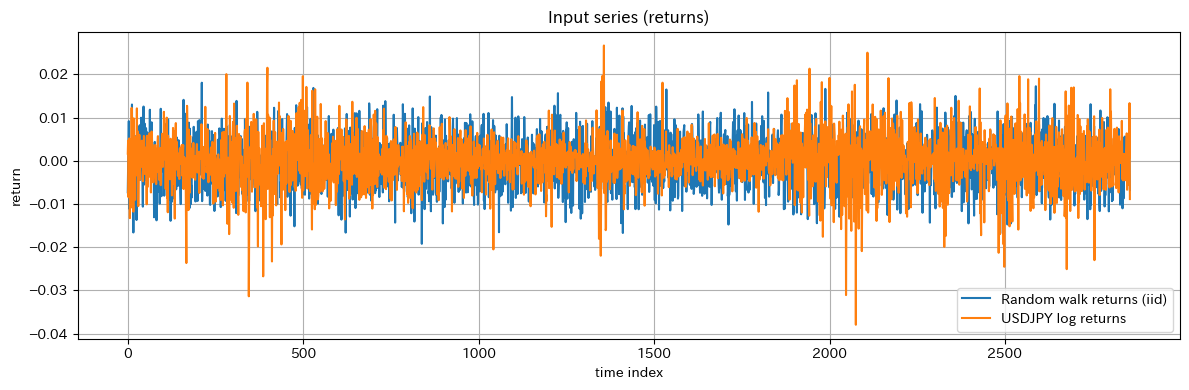

Scales: [ 10  12  14  17  21  25  31  37  45  54  66  80  97 117 141 171 206 249]


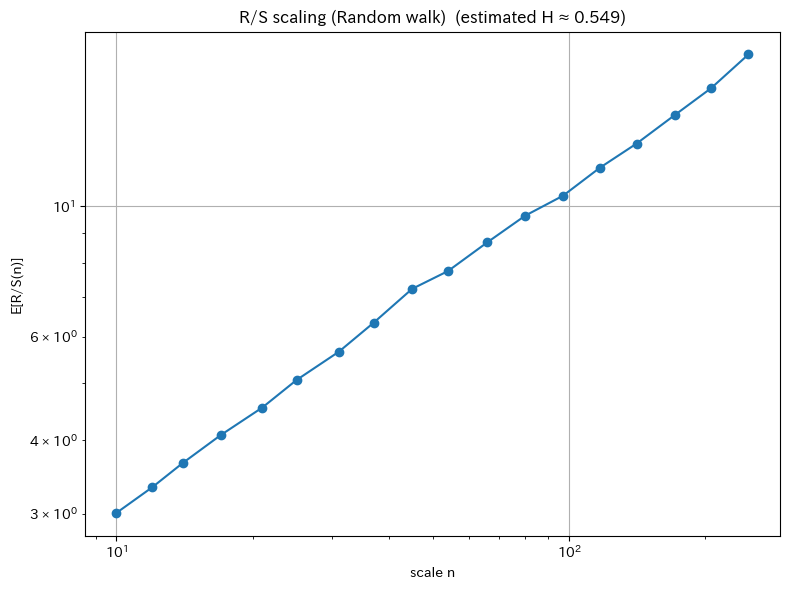

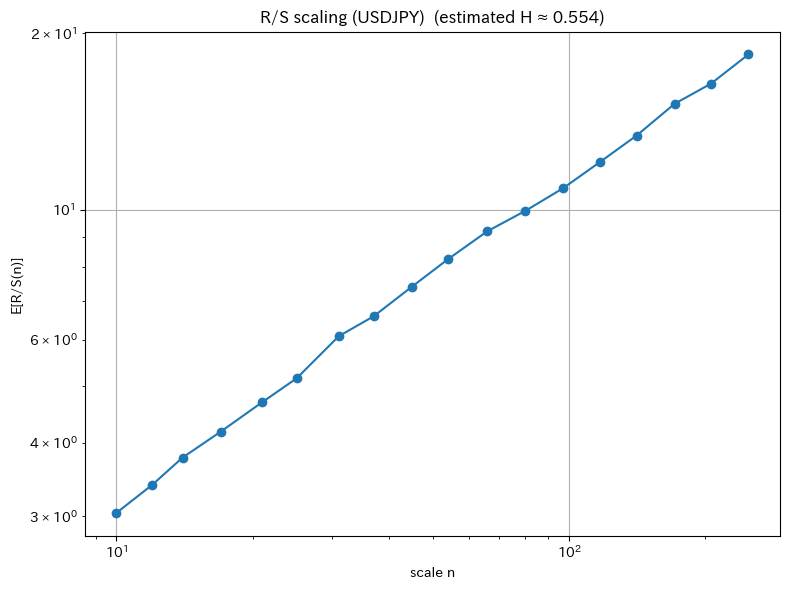

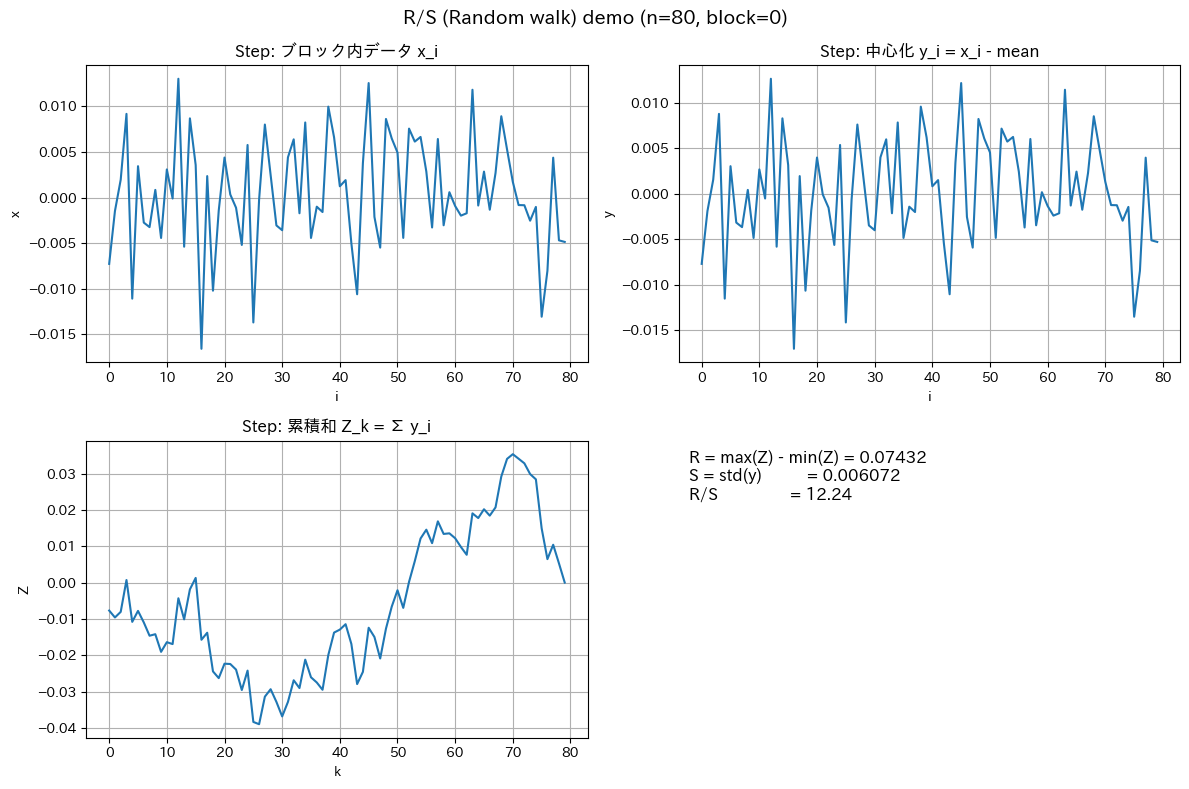

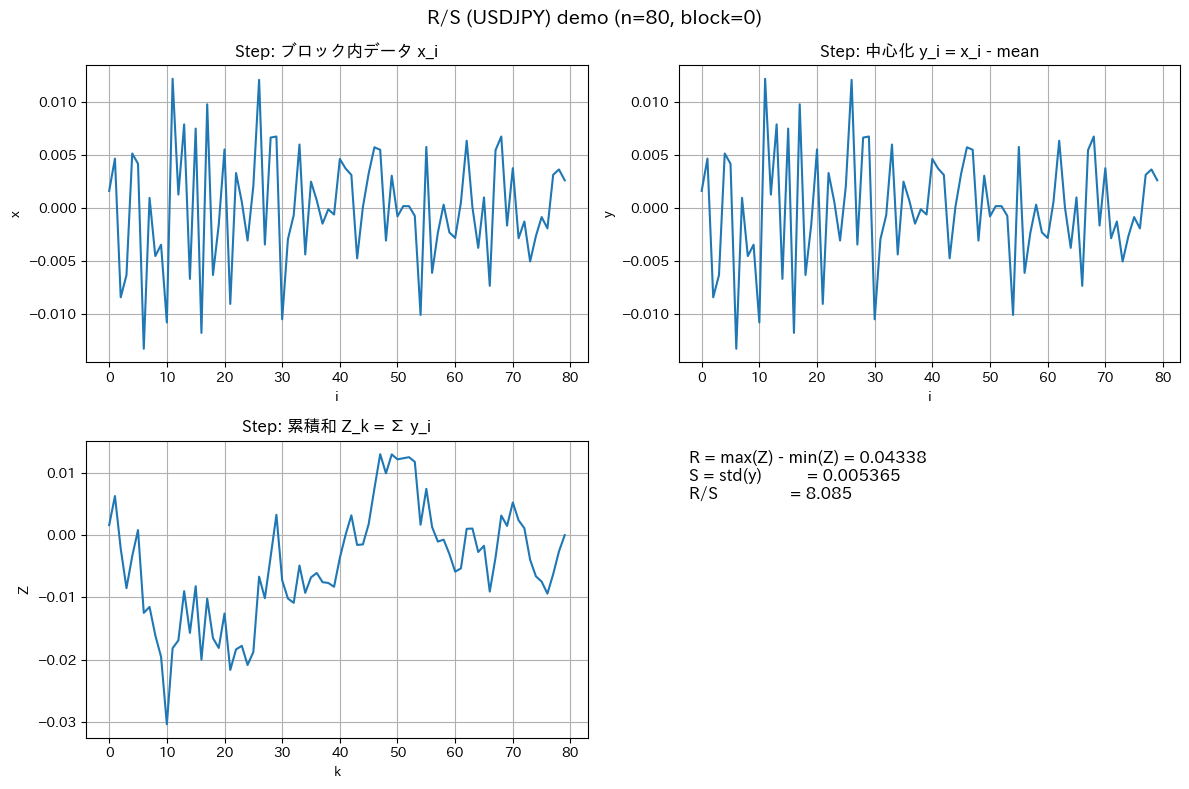

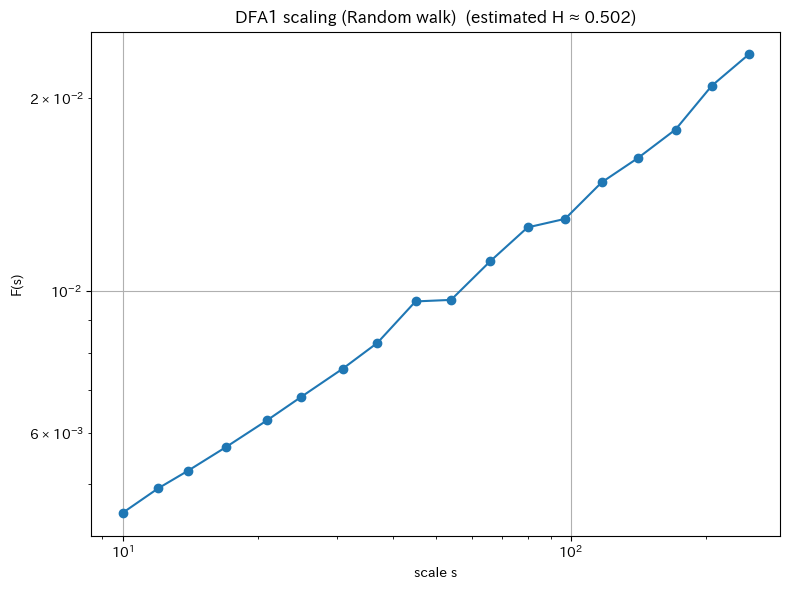

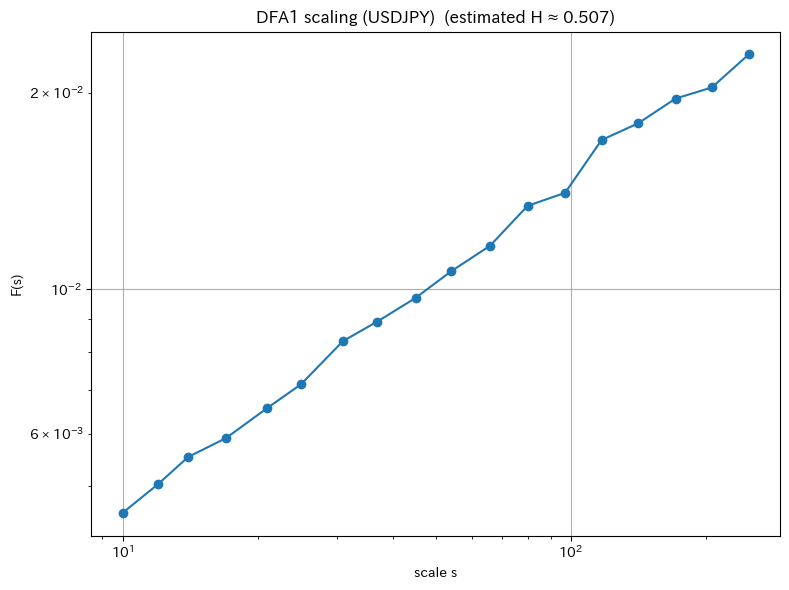

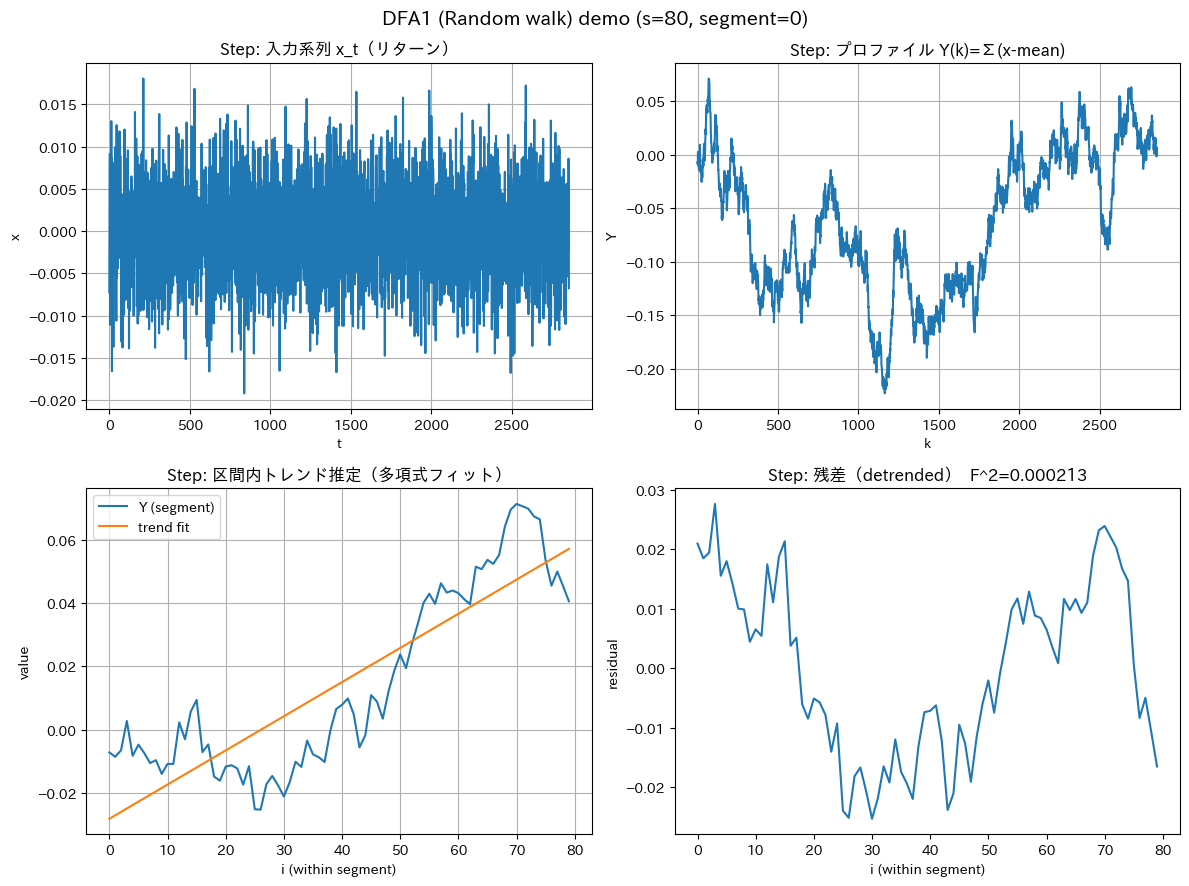

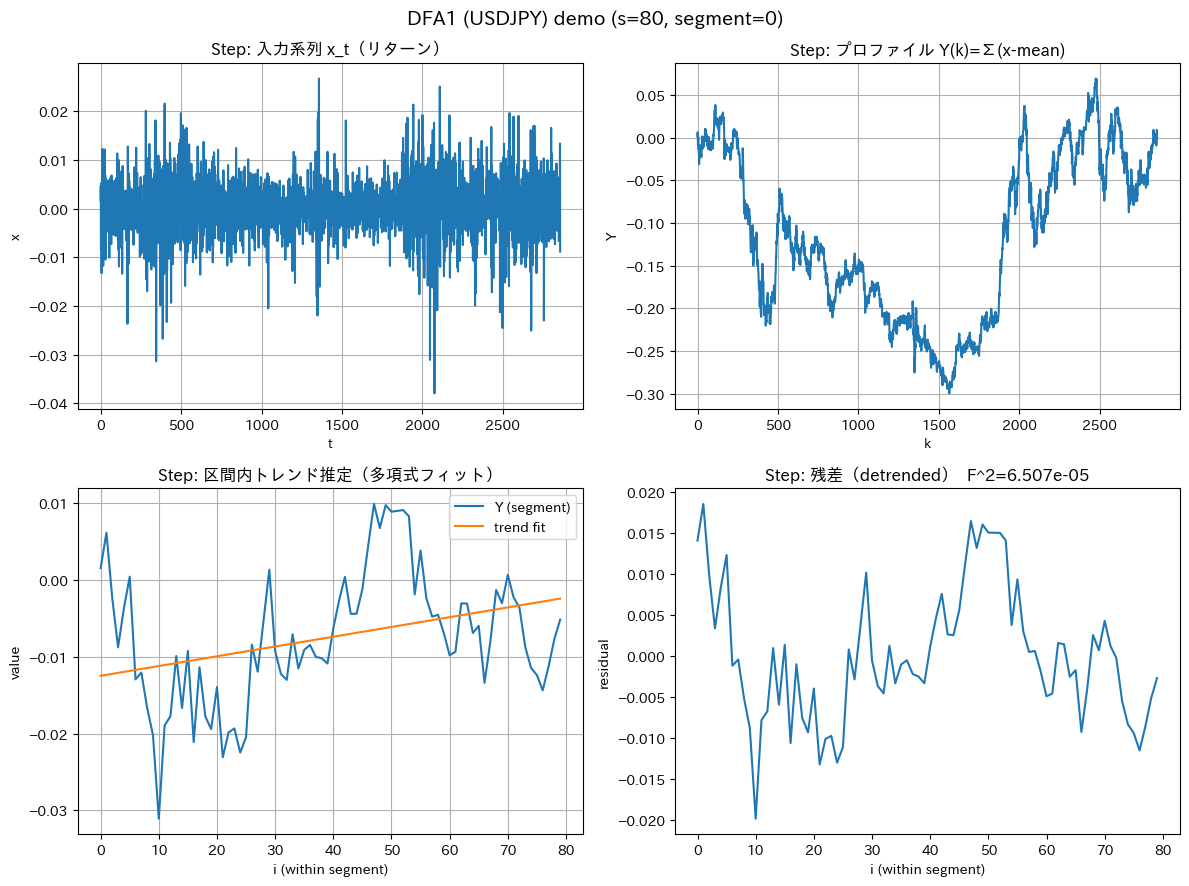


Estimated H:
  R/S  (Random walk): 0.549
  R/S  (USDJPY)     : 0.554
  DFA1 (Random walk): 0.502
  DFA1 (USDJPY)     : 0.507


In [5]:
# -----------------------------
# Main: run both methods on (1) random walk and (2) USDJPY log returns
# -----------------------------
# Settings
START_DATE = "2015-01-01"
DEMO_SCALE_RS = 80      # R/Sのデモ用ブロック長 n
DEMO_BLOCK_RS = 0       # そのスケールの何番目ブロックを可視化するか
DEMO_SCALE_DFA = 80     # DFAのデモ用スケール s
DEMO_SEG_DFA = 0        # そのスケールの何番目区間を可視化するか
DFA_ORDER = 1           # DFA1（線形デトレンド）

# 1) Fetch USDJPY and returns
price = fetch_usdjpy_daily(start=START_DATE)
ret_fx = to_log_returns(price)

# 2) Create a random-walk benchmark with same length (returns iid normal)
#    ランダムウォークの「リターン」を生成（iid）し、比較対象にする
N = len(ret_fx)
ret_rw = pd.Series(np.random.normal(loc=0.0, scale=ret_fx.std(), size=N), index=ret_fx.index, name="rw_return")

# Plot raw series
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(ret_rw.values, label="Random walk returns (iid)")
ax.plot(ret_fx.values, label="USDJPY log returns")
ax.set_title("Input series (returns)")
ax.set_xlabel("time index")
ax.set_ylabel("return")
ax.legend()
plt.tight_layout()
plt.grid()
plt.show()

# Choose scales
scales = default_scales(N, min_s=10, max_s=min(250, N//4), num=18)
print("Scales:", scales)

# -----------------------------
# R/S
# -----------------------------
rs_rw, H_rs_rw, demos_rs_rw = rs_analysis(ret_rw.values, scales)
rs_fx, H_rs_fx, demos_rs_fx = rs_analysis(ret_fx.values, scales)

plot_rs_scaling(scales, rs_rw, H_rs_rw, title="R/S scaling (Random walk)")
plot_rs_scaling(scales, rs_fx, H_rs_fx, title="R/S scaling (USDJPY)")

# Step-by-step demo (R/S) for chosen scale and block
def pick_rs_demo(demos_by_scale, n, block):
    demos = demos_by_scale.get(int(n), [])
    if not demos:
        raise ValueError(f"No demos for n={n}. Choose a scale that yields at least 2 blocks.")
    block = int(np.clip(block, 0, len(demos)-1))
    return demos[block]

demo_rs_rw = pick_rs_demo(demos_rs_rw, DEMO_SCALE_RS, DEMO_BLOCK_RS)
demo_rs_fx = pick_rs_demo(demos_rs_fx, DEMO_SCALE_RS, DEMO_BLOCK_RS)

plot_rs_steps(demo_rs_rw, title_prefix="R/S (Random walk)")
plot_rs_steps(demo_rs_fx, title_prefix="R/S (USDJPY)")

# -----------------------------
# DFA
# -----------------------------
Fs_rw, H_dfa_rw, demos_dfa_rw, profile_rw = dfa_analysis(ret_rw.values, scales, order=DFA_ORDER)
Fs_fx, H_dfa_fx, demos_dfa_fx, profile_fx = dfa_analysis(ret_fx.values, scales, order=DFA_ORDER)

plot_dfa_scaling(scales, Fs_rw, H_dfa_rw, title=f"DFA{DFA_ORDER} scaling (Random walk)")
plot_dfa_scaling(scales, Fs_fx, H_dfa_fx, title=f"DFA{DFA_ORDER} scaling (USDJPY)")

# Step-by-step demo (DFA) for chosen scale and segment
def pick_dfa_demo(demos_by_scale, s, seg):
    demos = demos_by_scale.get(int(s), [])
    if not demos:
        raise ValueError(f"No demos for s={s}. Choose a scale that yields at least 2 segments.")
    seg = int(np.clip(seg, 0, len(demos)-1))
    return demos[seg]

demo_dfa_rw = pick_dfa_demo(demos_dfa_rw, DEMO_SCALE_DFA, DEMO_SEG_DFA)
demo_dfa_fx = pick_dfa_demo(demos_dfa_fx, DEMO_SCALE_DFA, DEMO_SEG_DFA)

plot_dfa_steps(ret_rw.values, profile_rw, demo_dfa_rw, title_prefix=f"DFA{DFA_ORDER} (Random walk)")
plot_dfa_steps(ret_fx.values, profile_fx, demo_dfa_fx, title_prefix=f"DFA{DFA_ORDER} (USDJPY)")

# -----------------------------
# Quick summary
# -----------------------------
print("\nEstimated H:")
print(f"  R/S  (Random walk): {H_rs_rw:.3f}")
print(f"  R/S  (USDJPY)     : {H_rs_fx:.3f}")
print(f"  DFA{DFA_ORDER} (Random walk): {H_dfa_rw:.3f}")
print(f"  DFA{DFA_ORDER} (USDJPY)     : {H_dfa_fx:.3f}")

# Tips:
# - スケール範囲を変える（scales）
# - DFAの次数を変える（DFA_ORDER=2等）
# - DEMO_SCALE_RS / DEMO_SCALE_DFA を変えて「中間ステップ」がどう変化するか確認


method	N	n_seeds	mean	std	bias	rmse
DFA1	250	200	0.4930	0.0842	-0.0070	0.0843
DFA1	500	200	0.5033	0.0586	+0.0033	0.0586
DFA1	1000	200	0.5004	0.0413	+0.0004	0.0412
DFA1	2000	200	0.4999	0.0328	-0.0001	0.0327
DFA1	4000	200	0.4982	0.0270	-0.0018	0.0270
DFA1	8000	200	0.5002	0.0226	+0.0002	0.0225
R/S	250	200	0.5810	0.0664	+0.0810	0.1047
R/S	500	200	0.5786	0.0444	+0.0786	0.0903
R/S	1000	200	0.5674	0.0311	+0.0674	0.0742
R/S	2000	200	0.5591	0.0248	+0.0591	0.0641
R/S	4000	200	0.5507	0.0201	+0.0507	0.0545
R/S	8000	200	0.5456	0.0169	+0.0456	0.0486


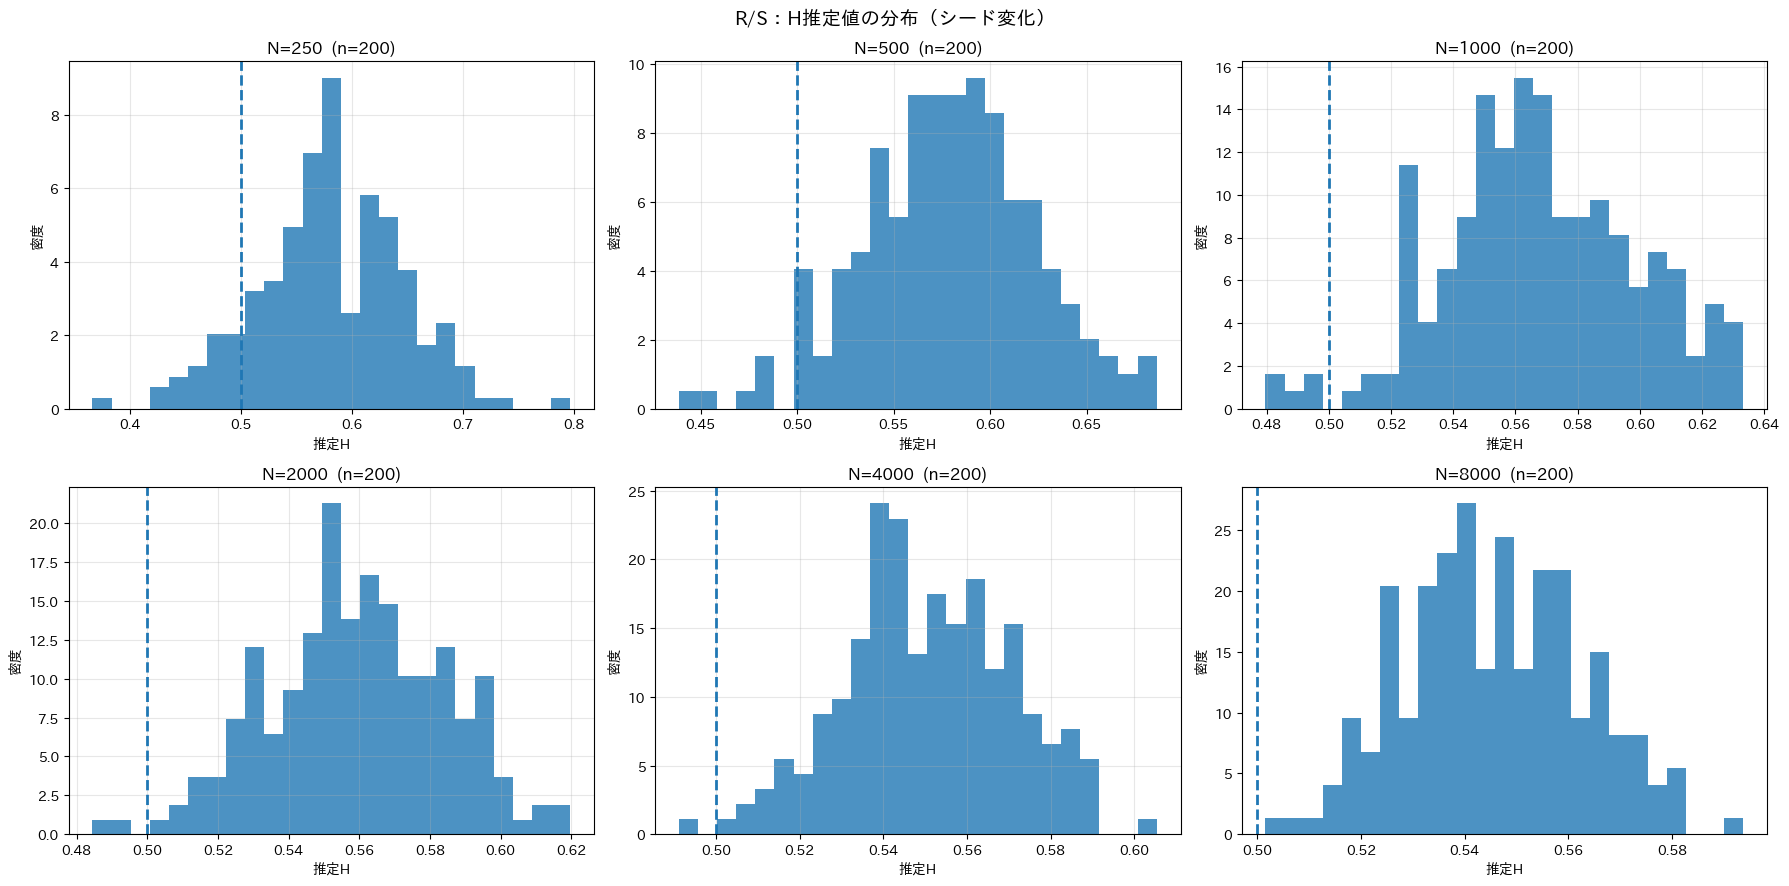

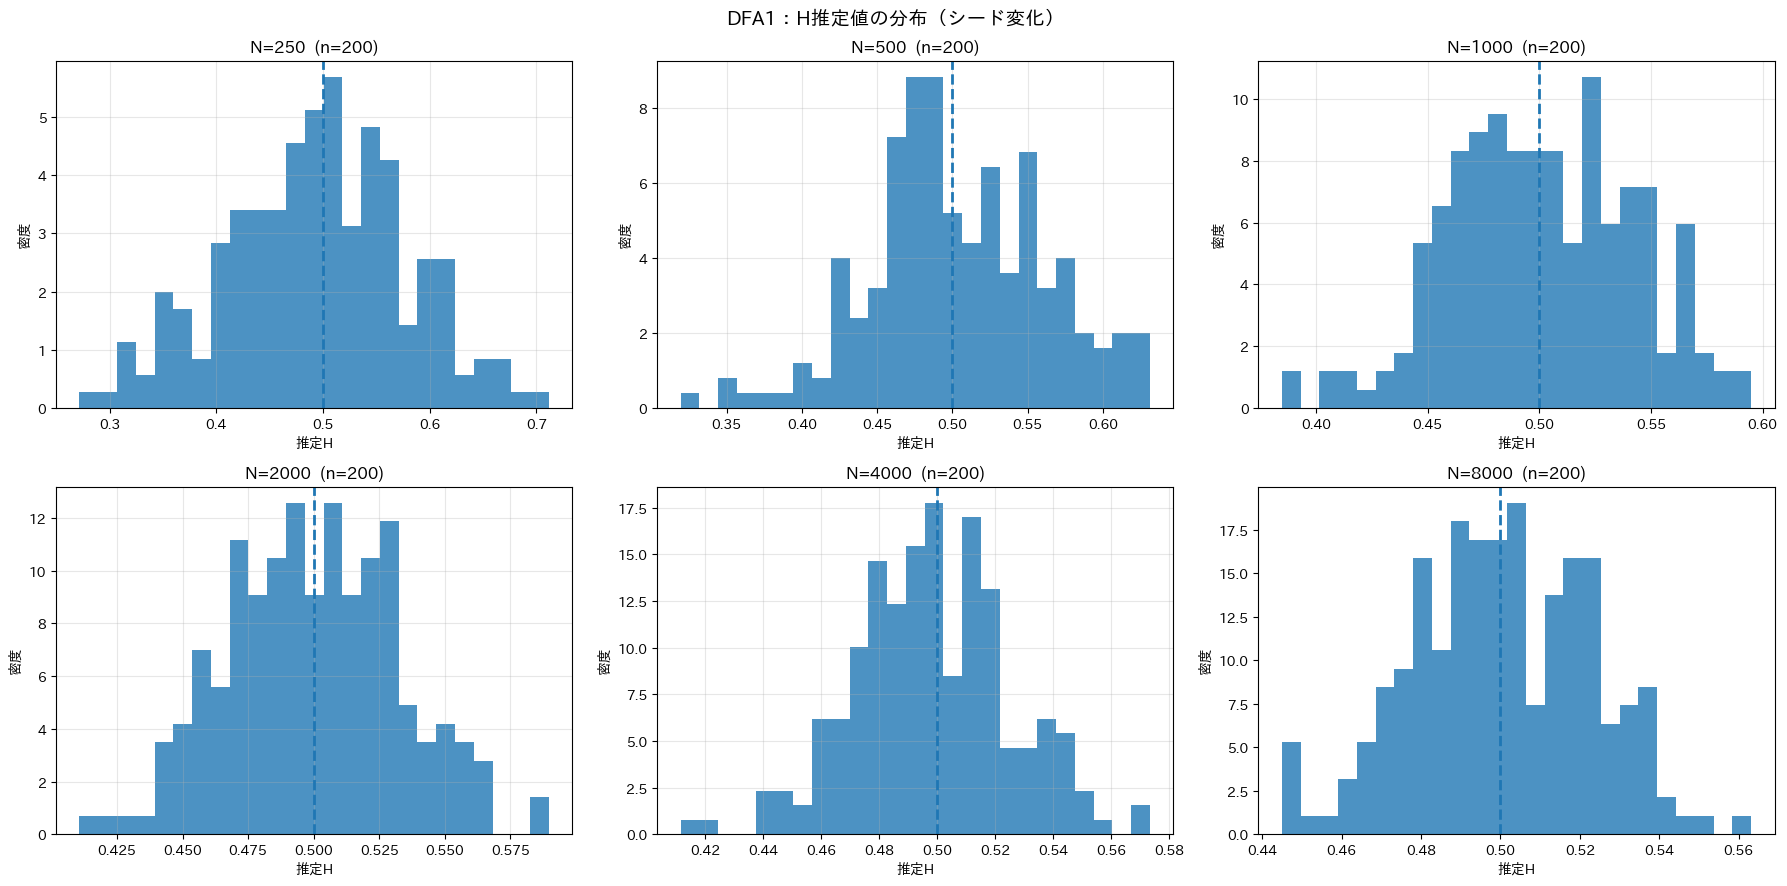

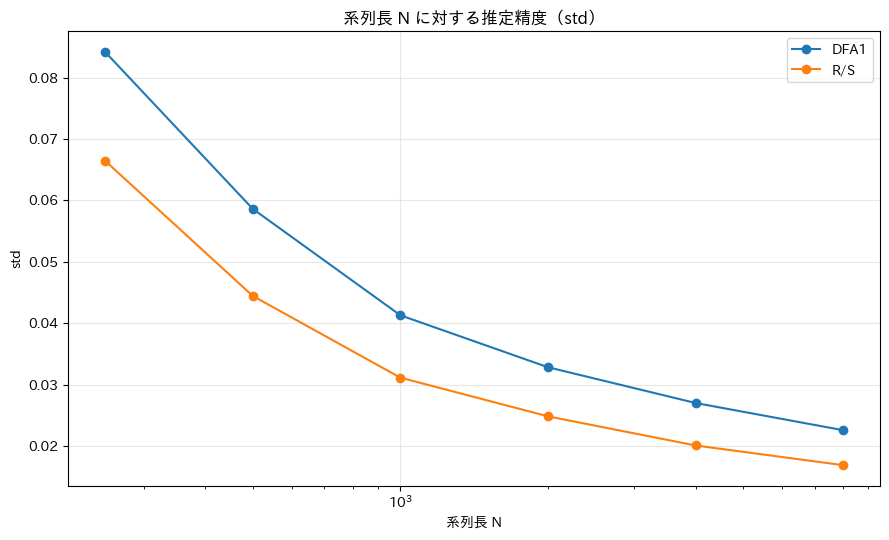

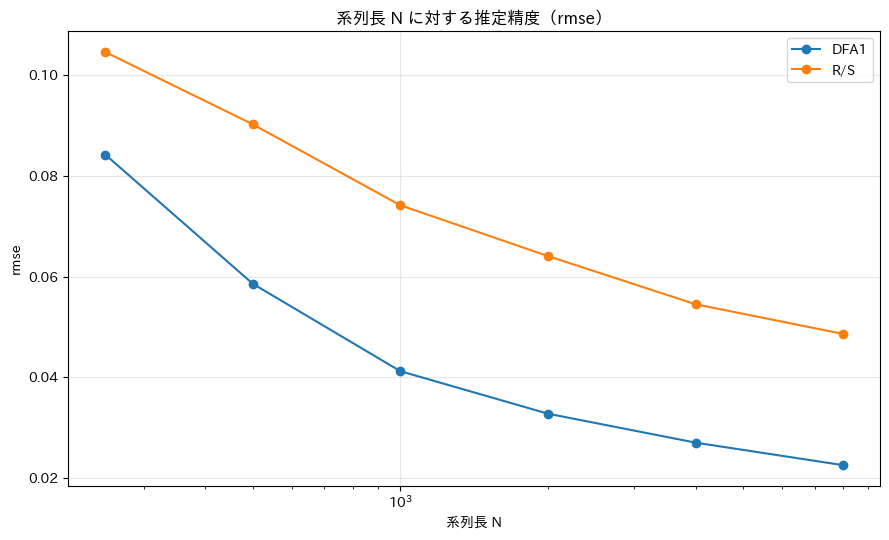

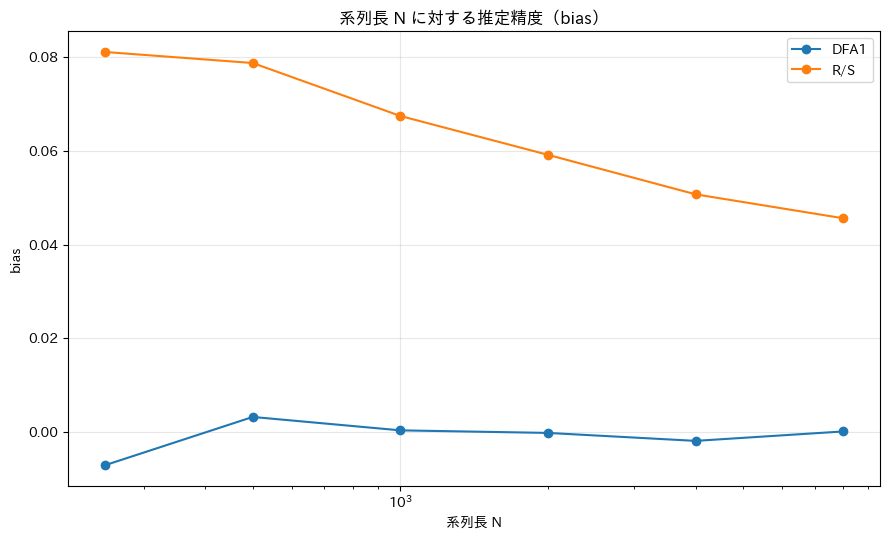

In [6]:
# Colab / Jupyter 用：ランダムウォーク（iidリターン）に対して
# R/S と DFA の推定Hを、seedを変えて分布として可視化し、
# 系列長 N を変えたときの推定精度（平均・標準偏差・RMSE等）を比較するコード。
#
# 日本語フォント：japanize_matplotlib を使用
!pip -q install japanize-matplotlib

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401 (importするだけで日本語フォント設定)
from dataclasses import dataclass

np.random.seed(0)

# -----------------------------
# Scales (window sizes)
# -----------------------------
def make_scales(N: int, min_s: int = 10, max_s: int | None = None, num: int = 18) -> np.ndarray:
    if max_s is None:
        max_s = max(50, N // 5)
    max_s = min(max_s, N // 2)
    if max_s <= min_s:
        return np.array([], dtype=int)
    scales = np.unique(np.logspace(np.log10(min_s), np.log10(max_s), num=num).astype(int))
    scales = scales[(scales >= min_s) & (scales <= max_s)]
    return scales

# -----------------------------
# R/S analysis
# -----------------------------
def rs_mean_for_scale(x: np.ndarray, n: int) -> float:
    N = len(x)
    m = N // n
    if m < 2:
        return np.nan

    rs_vals = []
    for b in range(m):
        block = x[b*n:(b+1)*n]
        mu = block.mean()
        centered = block - mu
        cumdev = np.cumsum(centered)
        R = cumdev.max() - cumdev.min()
        S = centered.std(ddof=0)
        if S == 0:
            rs_vals.append(np.nan)
        else:
            rs_vals.append(R / S)
    return float(np.nanmean(rs_vals))

def estimate_h_rs(x: np.ndarray, scales: np.ndarray) -> float:
    rs_means = np.array([rs_mean_for_scale(x, int(n)) for n in scales], dtype=float)
    valid = np.isfinite(rs_means) & (rs_means > 0)
    if valid.sum() < 3:
        return np.nan
    slope, intercept = np.polyfit(np.log(scales[valid]), np.log(rs_means[valid]), 1)
    return float(slope)

# -----------------------------
# DFA (order=1)
# -----------------------------
def dfa_F_for_scale(x: np.ndarray, s: int, order: int = 1) -> float:
    N = len(x)
    y = x - x.mean()
    Y = np.cumsum(y)  # profile
    Ns = N // s
    if Ns < 2:
        return np.nan

    F2_list = []
    t = np.arange(s)

    for v in range(Ns):
        seg = Y[v*s:(v+1)*s]
        coef = np.polyfit(t, seg, order)
        trend = np.polyval(coef, t)
        resid = seg - trend
        F2_list.append(np.mean(resid**2))

    return float(np.sqrt(np.mean(F2_list)))

def estimate_h_dfa(x: np.ndarray, scales: np.ndarray, order: int = 1) -> float:
    Fs = np.array([dfa_F_for_scale(x, int(s), order=order) for s in scales], dtype=float)
    valid = np.isfinite(Fs) & (Fs > 0)
    if valid.sum() < 3:
        return np.nan
    slope, intercept = np.polyfit(np.log(scales[valid]), np.log(Fs[valid]), 1)
    return float(slope)

# -----------------------------
# Simulation
# -----------------------------
@dataclass
class Summary:
    N: int
    method: str
    n_seeds: int
    mean: float
    std: float
    bias: float
    rmse: float

def simulate_h_distribution(
    Ns=(250, 500, 1000, 2000, 4000),
    n_seeds=200,
    sigma=1.0,
    min_scale=10,
    max_scale_frac=0.2,   # max scale = N * frac
    n_scales=18,
    dfa_order=1,
    true_H=0.5
):
    results = {}  # (method, N) -> H estimates array
    summaries = []

    for N in Ns:
        scales = make_scales(
            N=N,
            min_s=min_scale,
            max_s=max(min_scale+1, int(N*max_scale_frac)),
            num=n_scales
        )
        if len(scales) < 3:
            print(f"[WARN] N={N}: scalesが不足（{len(scales)}）のためスキップ")
            continue

        H_rs_list = []
        H_dfa_list = []

        for seed in range(n_seeds):
            rng = np.random.default_rng(seed)
            x = rng.normal(loc=0.0, scale=sigma, size=N)  # iid returns (random walk increments)

            H_rs = estimate_h_rs(x, scales)
            H_dfa = estimate_h_dfa(x, scales, order=dfa_order)
            H_rs_list.append(H_rs)
            H_dfa_list.append(H_dfa)

        H_rs_arr = np.array(H_rs_list, dtype=float)
        H_dfa_arr = np.array(H_dfa_list, dtype=float)

        for method, arr in [("R/S", H_rs_arr), (f"DFA{dfa_order}", H_dfa_arr)]:
            valid = np.isfinite(arr)
            arrv = arr[valid]
            results[(method, N)] = arrv

            mean = float(np.mean(arrv))
            std = float(np.std(arrv, ddof=1)) if len(arrv) > 1 else np.nan
            bias = mean - true_H
            rmse = float(np.sqrt(np.mean((arrv - true_H)**2)))

            summaries.append(Summary(
                N=N, method=method, n_seeds=int(len(arrv)),
                mean=mean, std=std, bias=bias, rmse=rmse
            ))

    return results, summaries

# -----------------------------
# Plotting helpers
# -----------------------------
def plot_hist_grid(results, Ns, method, bins=25):
    # Nsの数に応じて横に並べる
    cols = min(3, len(Ns))
    rows = int(np.ceil(len(Ns) / cols))
    fig = plt.figure(figsize=(6*cols, 4.5*rows))
    fig.suptitle(f"{method}：H推定値の分布（シード変化）", fontsize=14)

    for i, N in enumerate(Ns):
        ax = fig.add_subplot(rows, cols, i+1)
        arr = results.get((method, N), None)
        if arr is None or len(arr) == 0:
            ax.set_title(f"N={N}（データなし）")
            ax.axis("off")
            continue

        ax.hist(arr, bins=bins, density=True, alpha=0.8)
        ax.axvline(0.5, linestyle="--", linewidth=2)
        ax.set_title(f"N={N}  (n={len(arr)})")
        ax.set_xlabel("推定H")
        ax.set_ylabel("密度")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.grid()
    plt.show()

def plot_error_vs_N(summaries, Ns, metric="rmse"):
    # metric: "std" or "rmse" or "bias"
    methods = sorted(set(s.method for s in summaries))
    fig = plt.figure(figsize=(9, 5.5))
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title(f"系列長 N に対する推定精度（{metric}）")
    ax.set_xlabel("系列長 N")
    ax.set_ylabel(metric)

    for method in methods:
        xs, ys = [], []
        for N in Ns:
            cand = [s for s in summaries if s.method == method and s.N == N]
            if not cand:
                continue
            xs.append(N)
            ys.append(getattr(cand[0], metric))
        if xs:
            ax.plot(xs, ys, marker="o", label=method)

    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

def print_summary_table(summaries):
    # 簡易表示（pandasなし）
    summaries = sorted(summaries, key=lambda s: (s.method, s.N))
    print("method\tN\tn_seeds\tmean\tstd\tbias\trmse")
    for s in summaries:
        print(f"{s.method}\t{s.N}\t{s.n_seeds}\t{s.mean:.4f}\t{s.std:.4f}\t{s.bias:+.4f}\t{s.rmse:.4f}")

# -----------------------------
# Run (settings)
# -----------------------------
Ns = (250, 500, 1000, 2000, 4000, 8000)   # 系列長を比較（必要に応じて増減）
N_SEEDS = 200                             # シード数（精度↑ほど計算量↑）
SIGMA = 1.0                               # 増分の標準偏差（H推定には本質的に影響しない）
MIN_SCALE = 10
MAX_SCALE_FRAC = 0.2                      # 最大スケール = N * 0.2
N_SCALES = 18
DFA_ORDER = 1                             # DFA1

results, summaries = simulate_h_distribution(
    Ns=Ns,
    n_seeds=N_SEEDS,
    sigma=SIGMA,
    min_scale=MIN_SCALE,
    max_scale_frac=MAX_SCALE_FRAC,
    n_scales=N_SCALES,
    dfa_order=DFA_ORDER,
    true_H=0.5
)

print_summary_table(summaries)

# -----------------------------
# Distributions
# -----------------------------
plot_hist_grid(results, Ns, method="R/S", bins=25)
plot_hist_grid(results, Ns, method=f"DFA{DFA_ORDER}", bins=25)

# -----------------------------
# Accuracy vs N
# -----------------------------
plot_error_vs_N(summaries, Ns, metric="std")
plot_error_vs_N(summaries, Ns, metric="rmse")
plot_error_vs_N(summaries, Ns, metric="bias")


# -----------------------------
# Tuning tips (optional)
# -----------------------------
# 1) スケール範囲の感度を見たいなら MAX_SCALE_FRAC を 0.1 / 0.25 / 0.33 などで比較
# 2) スケール数 N_SCALES を増やすと回帰が安定することがある（計算量↑）
# 3) DFA_ORDER を 2 にするとトレンド耐性が変わる（ランダムウォークでは大差は出にくいはず）
# 4) 速度が厳しければ N_SEEDS を減らす / Nsを減らす
